In [1]:
%%capture

!pip uninstall -y numpy
!pip install  numpy==1.26.4
!pip install monai

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm import tqdm
import glob
import torch
import numpy as np


from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism
from monai.data import Dataset, DataLoader, CacheDataset, DataLoader, partition_dataset
from monai.bundle import download, load,ConfigParser
from monai.transforms import (
    Compose, LoadImaged, ScaleIntensityd, ToTensord,EnsureChannelFirstd,RandCropByPosNegLabeld,
    RandRotate90d, RandFlipd, RandZoomd, RandGaussianNoised, CropForegroundd
)


In [7]:
set_determinism(seed=0)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
%%capture
bundle_dir = "prostate_mri_anatomy"
download(name=bundle_dir, bundle_dir=".", progress=True)

2025-04-26 01:12:18,235 - INFO - --- input summary of monai.bundle.scripts.download ---
2025-04-26 01:12:18,237 - INFO - > name: 'prostate_mri_anatomy'
2025-04-26 01:12:18,237 - INFO - > bundle_dir: '.'
2025-04-26 01:12:18,238 - INFO - > source: 'monaihosting'
2025-04-26 01:12:18,239 - INFO - > remove_prefix: 'monai_'
2025-04-26 01:12:18,239 - INFO - > progress: True
2025-04-26 01:12:18,240 - INFO - ---


2025-04-26 01:12:18,414 - INFO - Expected md5 is None, skip md5 check for file prostate_mri_anatomy_v0.3.4.zip.
2025-04-26 01:12:18,415 - INFO - File exists: prostate_mri_anatomy_v0.3.4.zip, skipped downloading.
2025-04-26 01:12:18,416 - INFO - Writing into directory: ..


In [4]:
%%capture
!unzip "/content/file_data.zip"

In [9]:
csv_path = "/content/data.csv"
df = pd.read_csv(csv_path)

#store it into the data variables
data = [
    {"image": row["T2W_NIFTI"], "label": row["Gland_NIFTI"]}
    for _, row in df.iterrows()
]

#store paths of label an/d input images
data = [
    {'image': f"/content/file_data/{d['image']}", 'label': f"/content/file_data/{d['label']}"}
    for d in data

]
print(data)

[{'image': '/content/file_data/10005/10005_t2w.nii.gz', 'label': '/content/file_data/10005/10005_gland.nii.gz'}, {'image': '/content/file_data/10040/10040_t2w.nii.gz', 'label': '/content/file_data/10040/10040_gland.nii.gz'}, {'image': '/content/file_data/10043/10043_t2w.nii.gz', 'label': '/content/file_data/10043/10043_gland.nii.gz'}, {'image': '/content/file_data/10048/10048_t2w.nii.gz', 'label': '/content/file_data/10048/10048_gland.nii.gz'}, {'image': '/content/file_data/10059/10059_t2w.nii.gz', 'label': '/content/file_data/10059/10059_gland.nii.gz'}, {'image': '/content/file_data/10074/10074_t2w.nii.gz', 'label': '/content/file_data/10074/10074_gland.nii.gz'}, {'image': '/content/file_data/10085/10085_t2w.nii.gz', 'label': '/content/file_data/10085/10085_gland.nii.gz'}, {'image': '/content/file_data/10097/10097_t2w.nii.gz', 'label': '/content/file_data/10097/10097_gland.nii.gz'}, {'image': '/content/file_data/10107/10107_t2w.nii.gz', 'label': '/content/file_data/10107/10107_gland.n

In [10]:
#get the model path
bundle_dir = "prostate_mri_anatomy"
model_path = os.path.join(bundle_dir, "models", "model.pt")
print(model_path)

prostate_mri_anatomy/models/model.pt


In [11]:
#files that exist in the bundle directory
print(os.listdir(bundle_dir))
# models directory
models_dir = os.path.join(bundle_dir, "models")
if os.path.exists(models_dir):
    print(os.listdir(models_dir)) #['model.pt', 'model.ts'] pytorch model and TorchScript (faster)

['configs', 'models', 'docs', 'LICENSE', 'eval', 'scripts']
['model.ts', 'model.pt']


In [21]:
#get the model weights and parse the config file
config_parser = ConfigParser()
config_file = os.path.join(bundle_dir, "configs", "inference.json")
print(config_file)
if os.path.exists(config_file):
    model = torch.load(model_path, map_location=device)

    config_parser.read_config(config_file)
    network_def=config_parser.get_parsed_content("network_def", instantiate=True)
    network_def.load_state_dict(model)
    model=network_def
    print(config_parser.get("network_def", default=None))
    model.eval()
    model=model.to(device)

    print("Model loaded successfully!")

prostate_mri_anatomy/configs/inference.json
{'_target_': 'UNet', 'spatial_dims': 3, 'in_channels': 1, 'out_channels': 3, 'channels': [16, 32, 64, 128, 256, 512], 'strides': [2, 2, 2, 2, 2], 'num_res_units': 4, 'norm': 'batch', 'act': 'prelu', 'dropout': 0.15}
Model loaded successfully!


**Architecture**
</br>
Input (1 channel)</br>
   ↓
   </br>
Encoder Path (Downsampling)
   </br>
   ↓
   </br>
Bottleneck
  </br>
   ↓
   </br>
Decoder Path (Upsampling)
   </br>
   ↓
   </br>
Output (3 channels)


In [22]:

inf_transforms = config_parser.get_parsed_content("preprocessing")

dataset = Dataset(data=data, transform=inf_transforms)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [ ]:
#to check the dimensions of the loaded data
batch = next(iter(dataloader))
print(batch["image"].shape)
# print(batch["label"].shape)


Dice loss will be between 0 (perfect match) and 1 (complete mismatch).


The Dice score ranges from:

0: No overlap (completely different)

1: Perfect match (exact overlap)

In [ ]:
loss_function = DiceLoss(to_onehot_y=True, softmax=True) #softmax true as output has 3 channels - multi segmentation
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")

In [ ]:
max_epochs = 3
val_interval = 5
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

In [ ]:
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.transforms import Activations, AsDiscrete

In [14]:
import os
import torch
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from monai.transforms import AsDiscreted
from monai.data import decollate_batch
import nibabel as nib


# Get inferer from the parsed config
inferer = config_parser.get_parsed_content("inferer")

# Create output directory if it doesn't exist
output_dir = os.path.join(bundle_dir, "eval")
os.makedirs(output_dir, exist_ok=True)

def test_model():
    model.eval()
    results = []
    inference_times = []

    with torch.no_grad():
        for batch_data in tqdm(dataloader, desc="Testing model on dataset"):
            inputs = batch_data["image"].to(device)

            start_time = time.time()

            outputs = inferer(inputs, model)

            inference_time = time.time() - start_time
            inference_times.append(inference_time)

            preds = torch.argmax(outputs, dim=1)

            for batch_idx in range(len(preds)):
                pred = preds[batch_idx].detach().cpu().numpy().astype(np.uint8)  # Convert to uint8

                if "image_meta_dict" in batch_data:
                    meta_dict = batch_data["image_meta_dict"][batch_idx]
                    filename = os.path.basename(meta_dict["filename_or_obj"])
                else:
                    filename = f"prediction_{len(results)}.nii.gz"

                # Save the prediction
                output_file = os.path.join(output_dir, filename)

                affine = np.eye(4)
                if "affine" in batch_data:
                    affine = batch_data["affine"][batch_idx].detach().cpu().numpy()
                nib_img = nib.Nifti1Image(pred, affine, dtype=np.uint8)
                nib.save(nib_img, output_file)
                save_success = True


                results.append({
                    "filename": filename,
                    "shape": pred.shape,
                    "unique_labels": np.unique(pred).tolist(),
                    "saved": save_success
                })

    # Print summary statistics
    print(f"Processed {len(results)} images")
    print(f"Average inference time: {sum(inference_times)/len(inference_times):.4f} seconds")

    # Visualize a sample prediction
    if len(results) > 0:
        sample_idx = 0
        plt.figure(figsize=(15, 5))

        # Get a sample batch
        sample_batch = next(iter(dataloader))
        sample_image = sample_batch["image"][sample_idx, 0].detach().cpu().numpy()
        label_path = sample_batch["label"][sample_idx]
        label_nii = nib.load(label_path)
        sample_label = label_nii.get_fdata().astype(np.uint8)

        middle_slice_idx = sample_image.shape[2] // 2

        # Original image
        plt.subplot(1, 4, 1)
        plt.imshow(sample_image[:, :, middle_slice_idx], cmap="gray")
        plt.title("Original Image")
        plt.axis('off')

        # Ground Truth Label
        plt.subplot(1, 4, 2)
        plt.imshow(sample_label[:, :, middle_slice_idx], cmap="viridis")
        plt.title("Ground Truth")
        plt.axis('off')

        # Get prediction
        with torch.no_grad():
            pred = inferer(sample_batch["image"].to(device), model)
            pred_argmax = torch.argmax(pred, dim=1)[sample_idx].detach().cpu().numpy()

        # Predicted Segmentation
        plt.subplot(1, 4, 3)
        plt.imshow(pred_argmax[:, :, middle_slice_idx], cmap="viridis")
        plt.title("Prediction")
        plt.axis('off')

        # Overlay
        plt.subplot(1, 4, 4)
        plt.imshow(sample_image[:, :, middle_slice_idx], cmap="gray")
        mask = np.ma.masked_where(pred_argmax[:, :, middle_slice_idx] == 0, pred_argmax[:, :, middle_slice_idx])
        plt.imshow(mask, alpha=0.7, cmap="cool")
        plt.title("Overlay")
        plt.axis('off')

        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "sample_prediction.png"))
        plt.close()

        # Save slice-by-slice visualizations
        visualize_dir = os.path.join(output_dir, "visualizations")
        os.makedirs(visualize_dir, exist_ok=True)

        for z in range(0, pred_argmax.shape[2], max(1, pred_argmax.shape[2] // 10)):  # Save ~10 slices
            plt.figure(figsize=(16, 4))

            plt.subplot(1, 4, 1)
            plt.imshow(sample_image[:, :, z], cmap="gray")
            plt.title(f"Original - Slice {z}")
            plt.axis('off')

            plt.subplot(1, 4, 2)
            # Ensure label and prediction have same shape along axis 2 (depth)
            min_depth = min(sample_label.shape[2], pred_argmax.shape[2], sample_image.shape[2])
            z = min(z, min_depth - 1)

            label_slice = sample_label[:, :, z]
            if label_slice.shape != sample_image[:, :, z].shape:
                # Resize label to match the image shape (for display)
                from skimage.transform import resize
                label_slice = resize(label_slice, sample_image[:, :, z].shape, order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)

            plt.imshow(label_slice, cmap="viridis")
            plt.title(f"Ground Truth - Slice {z}")
            plt.axis('off')

            plt.subplot(1, 4, 3)
            plt.imshow(pred_argmax[:, :, z], cmap="viridis")
            plt.title(f"Prediction - Slice {z}")
            plt.axis('off')

            plt.subplot(1, 4, 4)
            plt.imshow(sample_image[:, :, z], cmap="gray")
            mask = np.ma.masked_where(pred_argmax[:, :, z] == 0, pred_argmax[:, :, z])
            plt.imshow(mask, alpha=0.7, cmap="cool")
            plt.title(f"Overlay - Slice {z}")
            plt.axis('off')

            plt.tight_layout()
            plt.savefig(os.path.join(visualize_dir, f"slice_{z:03d}.png"))
            plt.close()
    return results

# Run the test
results = test_model()

Testing model on dataset: 100%|██████████| 5/5 [01:27<00:00, 17.41s/it]


Processed 10 images
Average inference time: 11.1758 seconds


In [15]:
# Print stats about segmentation results
if len(results) > 0:
    label_counts = {}
    for result in results:
        for label in result["unique_labels"]:
            label = int(label)
            if label not in label_counts:
                label_counts[label] = 0
            label_counts[label] += 1

    print("\nLabel distribution across all predictions:")
    for label, count in label_counts.items():
        if label == 0:
            name = "Background"
        elif label == 1:
            name = "Transition Zone (TZ)"
        elif label == 2:
            name = "Peripheral Zone (PZ)"
        else:
            name = f"Unknown Label {label}"

        print(f"  - {name}: found in {count}/{len(results)} images ({count/len(results)*100:.1f}%)")

    print("\nVolume statistics:")
    for label, name in [(1, "Transition Zone (TZ)"), (2, "Peripheral Zone (PZ)")]:
        volumes = []
        for batch_data in dataloader:
            with torch.no_grad():
                inputs = batch_data["image"].to(device)
                outputs = inferer(inputs, model)
                preds = torch.argmax(outputs, dim=1)

                for i in range(preds.shape[0]):
                    pred = preds[i].detach().cpu().numpy()

                    voxel_volume = 0.5 * 0.5 * 0.5  # mm³
                    volume_mm3 = np.sum(pred == label) * voxel_volume
                    volume_ml = volume_mm3 / 1000  # Convert to mL
                    volumes.append(volume_ml)

        if volumes:
            print(f"  - {name}: Mean volume = {np.mean(volumes):.2f} mL, "
                  f"Median = {np.median(volumes):.2f} mL, "
                  f"Range = [{np.min(volumes):.2f}, {np.max(volumes):.2f}] mL")

print(f"\nAll segmentation results saved to: {output_dir}")
print(f"Visualizations saved to: {os.path.join(output_dir, 'visualizations')}")


Label distribution across all predictions:
  - Background: found in 10/10 images (100.0%)
  - Transition Zone (TZ): found in 10/10 images (100.0%)
  - Peripheral Zone (PZ): found in 10/10 images (100.0%)

Volume statistics:
  - Transition Zone (TZ): Mean volume = 36.52 mL, Median = 33.99 mL, Range = [15.85, 60.55] mL
  - Peripheral Zone (PZ): Mean volume = 12.48 mL, Median = 12.34 mL, Range = [3.51, 23.80] mL

All segmentation results saved to: prostate_mri_anatomy/eval
Visualizations saved to: prostate_mri_anatomy/eval/visualizations


In [ ]:
#FINE TUNING

In [24]:

#get the model weights and parse the config file
config_parser = ConfigParser()
config_file = os.path.join(bundle_dir, "configs", "train4.json")
print(config_file)
if os.path.exists(config_file):
    model = torch.load(model_path, map_location=device)

    config_parser.read_config(config_file)
    network_def=config_parser.get_parsed_content("network_def", instantiate=True)
    network_def.load_state_dict(model)
    model=network_def
    print(config_parser.get("network_def", default=None))
    model.eval()
    print("Model loaded successfully!")

prostate_mri_anatomy/configs/train4.json
{'_target_': 'UNet', 'spatial_dims': 3, 'in_channels': 1, 'out_channels': 3, 'channels': [16, 32, 64, 128, 256, 512], 'strides': [2, 2, 2, 2, 2], 'num_res_units': 4, 'norm': 'batch', 'act': 'prelu', 'dropout': 0.15}
Model loaded successfully!


In [25]:

train_files, val_files = partition_dataset(
    data,
    ratios=[0.8, 0.2],
    shuffle=True,
    seed=42
)

In [26]:
val_transforms = config_parser.get_parsed_content("validate#preprocessing")
val_dataset = Dataset(data=data, transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=2,shuffle=True)

train_transforms = config_parser.get_parsed_content("train#preprocessing")
train_dataset = Dataset(data=data, transform=train_transforms)
train_loader = DataLoader(dataset, batch_size=2, shuffle=True)

In [27]:
# Create datasets
train_ds = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=1.0,
    num_workers=0,
)

val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=1.0,
    num_workers=0,
)

# Create data loaders
train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Loading dataset: 100%|██████████| 2/2 [00:06<00:00,  3.22s/it]


In [28]:


print(f"Training samples: {len(train_files)}, Validation samples: {len(val_files)}")


model = model.to(device)  # Your pre-trained model

# Define loss function, optimizer and metrics
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # Lower learning rate for fine-tuning
dice_metric = DiceMetric(include_background=False, reduction="mean")

max_epochs = 3
val_interval = 1
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

for epoch in range(max_epochs):
    print(f"Epoch {epoch + 1}/{max_epochs}")

    # Training phase
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in tqdm(train_loader):
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"Epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    # Validation phase
    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in tqdm(val_loader):
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                roi_size = (96, 96, 32)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)

                # Calculate metrics
                dice_metric(y_pred=val_outputs, y=val_labels)

            # Aggregate the final metric
            metric = dice_metric.aggregate().item()
            dice_metric.reset()

            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), "best_fine_tuned_model.pth")
                print("Saved new best model")

            print(f"Current epoch: {epoch + 1}, Current Dice: {metric:.4f}, Best Dice: {best_metric:.4f} at epoch {best_metric_epoch}")
            metric_values.append(metric)

print(f"Training completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")


Training samples: 8, Validation samples: 2
Epoch 1/3


100%|██████████| 4/4 [00:56<00:00, 14.12s/it]


Epoch 1 average loss: 0.6845


100%|██████████| 2/2 [00:08<00:00,  4.40s/it]


Saved new best model
Current epoch: 1, Current Dice: 0.0115, Best Dice: 0.0115 at epoch 1
Epoch 2/3


...

Current epoch: 2, Current Dice: 0.0115, Best Dice: 0.0115 at epoch 1
Epoch 3/3


100%|██████████| 4/4 [00:53<00:00, 13.29s/it]


Epoch 3 average loss: 0.6310


100%|██████████| 2/2 [00:08<00:00,  4.19s/it]

Current epoch: 3, Current Dice: 0.0115, Best Dice: 0.0115 at epoch 1
Training completed, best_metric: 0.0115 at epoch: 1


In [29]:

plt.figure("Training Results", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(x, y)

plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
val_x = [val_interval * (i + 1) for i in range(len(metric_values))]
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.plot(val_x, metric_values)
plt.savefig("training_results.png")
plt.close()

/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.array CropForeground.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


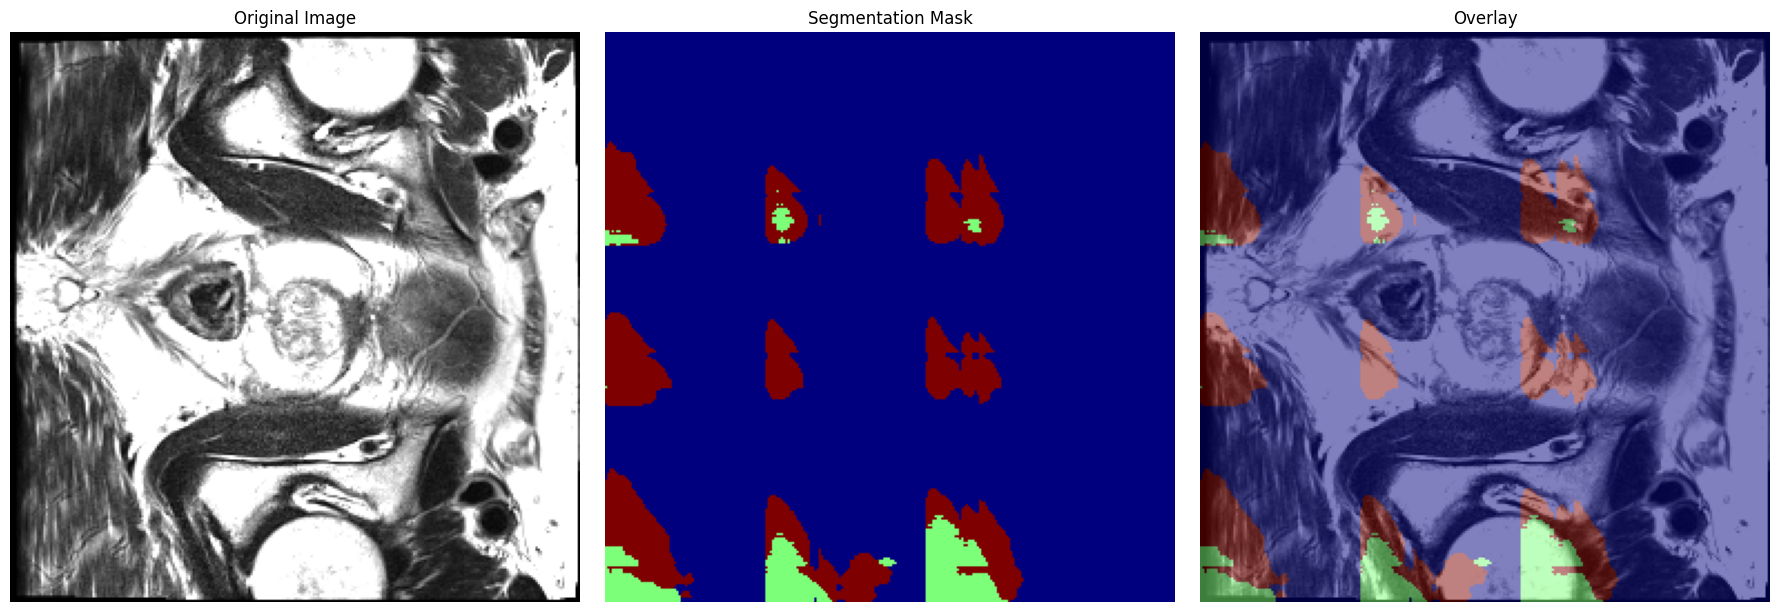

In [30]:
def test_on_single_image(image_path, model, device):
    from monai.transforms import (
        LoadImage,
        EnsureChannelFirst,
        Orientation,
        Spacing,
        ScaleIntensityRange,
        CropForeground,
        ToTensor,
        Compose
    )

    # Define transforms for the test image
    transforms = Compose([
        LoadImage(image_only=True),
        EnsureChannelFirst(),
        Orientation(axcodes="RAS"),
        Spacing(pixdim=(1.0, 1.0, 1.0), mode="bilinear"),
        ScaleIntensityRange(a_min=-175, a_max=250, b_min=0.0, b_max=1.0, clip=True),
        CropForeground(),
        ToTensor()
    ])

    # Load and transform the image
    test_image = transforms(image_path)
    test_image = test_image.unsqueeze(0).to(device)  # Add batch dimension

    # Run inference
    model.eval()
    with torch.no_grad():
        roi_size = (96, 96, 96)  # Match what you used during training
        sw_batch_size = 4
        test_output = sliding_window_inference(test_image, roi_size, sw_batch_size, model)

        # Get the segmentation mask
        if test_output.shape[1] > 1:  # Multi-class segmentation
            test_output = torch.softmax(test_output, dim=1)
            seg_mask = torch.argmax(test_output, dim=1).detach().cpu().numpy()
        else:  # Binary segmentation
            seg_mask = (test_output > 0.5).detach().cpu().numpy()

    # Convert to numpy for visualization
    test_image_np = test_image.detach().cpu().numpy()

    # Visualize middle slice
    plt.figure("Test Result", (18, 6))

    # Get middle slice
    slice_idx = test_image_np.shape[4] // 2

    # Original image
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(test_image_np[0, 0, :, :, slice_idx], cmap="gray")
    plt.axis('off')

    # Segmentation mask
    plt.subplot(1, 3, 2)
    plt.title("Segmentation Mask")
    plt.imshow(seg_mask[0, :, :, slice_idx], cmap="jet")
    plt.axis('off')

    # Overlay
    plt.subplot(1, 3, 3)
    plt.title("Overlay")
    plt.imshow(test_image_np[0, 0, :, :, slice_idx], cmap="gray")
    plt.imshow(seg_mask[0, :, :, slice_idx], cmap="jet", alpha=0.5)
    plt.axis('off')

    plt.tight_layout()
    plt.savefig("test_result.png")
    plt.show()

    return seg_mask

test_image_path = "file_data/10005/10005_t2w.nii.gz"
expected = "file_data/10005/10005_gland.nii.gz"

seg_mask = test_on_single_image(test_image_path, model, device)